# Rendering in 3D

For this notebook, I've written some code for drawing 3d primitives to 2d images, using OpenCV and NumPy, and a description of projection based on linear algebra operations, such as matrix multiplication, as one can see in a textbook for computer vision or computer graphics.

First we load the libraries that we need.

In [1]:
import cv2 as cv
import numpy as np
import IPython

Then we define the height and width of the image we'll produce, and show it as an IPython inline image.

In [2]:
width, height = 800, 600

In [3]:
img = cv.Mat(np.zeros((height, width)))
img

Mat([[0., 0., 0., ..., 0., 0., 0.],
     [0., 0., 0., ..., 0., 0., 0.],
     [0., 0., 0., ..., 0., 0., 0.],
     ...,
     [0., 0., 0., ..., 0., 0., 0.],
     [0., 0., 0., ..., 0., 0., 0.],
     [0., 0., 0., ..., 0., 0., 0.]], shape=(600, 800))

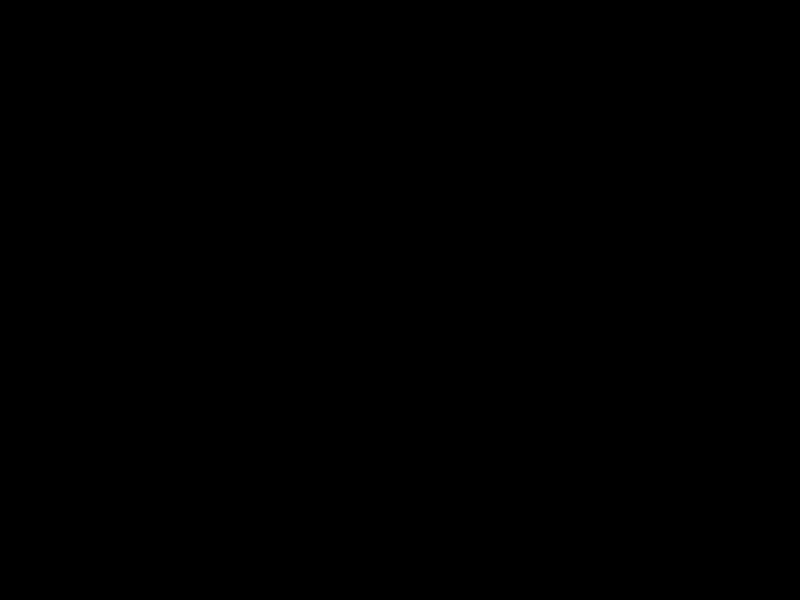

In [4]:
retval, buf = cv.imencode(".jpeg", img)
IPython.display.Image(bytes(buf))

We start defining some simple operations as homogeneous 4 by 4 matrices that will operate on 4 dimensional vectors, representing an x-y-z point and an homogeneous coordinate.

In [5]:
def translation_matrix3(t_x, t_y, t_z):
    return np.array([[1, 0, 0, t_x],
                     [0, 1, 0, t_y],
                     [0, 0, 1, t_z],
                     [0, 0, 0, 1]])

translation_matrix3(-1, 1, -2) @ np.array([1, 1, 1, 1])

array([ 0,  2, -1,  1])

For defining rotations around a vector, we need the matrix representation of the standard cross vector product, that we will define as a 3 by 3 matrix and later adapt to work with 4 by 4 matrices.

In [6]:
def cross_matrix(n):
    return np.array([[0, -n[2], n[1]],
                    [n[2], 0, -n[0]],
                    [-n[1], n[0], 0]])

np.array([1, 0, 0]) @ cross_matrix([0, 1, 0])

array([0, 0, 1])

What follows is an implementation of Rodriguez's formula to rotate a vector around a provided axis *n* by *theta* radians.

In [7]:
def rotation_matrix3(n, theta):
    sigma = cross_matrix(n)
    # resize cross product matrix to fit 4x4
    sigma = np.vstack((sigma, np.zeros((3,))))
    sigma = np.hstack((sigma, np.zeros((4,1))))
    return (np.identity(4) + np.sin(theta) * sigma + (1 - np.cos(theta)) * (sigma @ sigma))

translation_matrix3(1, 1, 2) @ rotation_matrix3([0, 0, 1], np.pi / 4)

array([[ 0.70710678, -0.70710678,  0.        ,  1.        ],
       [ 0.70710678,  0.70710678,  0.        ,  1.        ],
       [ 0.        ,  0.        ,  1.        ,  2.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

The following operation transforms an homogeneous vector or matrix whose homogeneous coordinate is not necessarily equal to 1, to an homogeneous matrix or vector.

In [8]:
def homogenize(v):
    if v.shape == (3, 3):
        v = v / v[2,2]
    elif v.shape == (3, ):
        v = v / v[2]
    elif v.shape == (4, 4):
        v = v / v[3,3]
    elif v.shape == (4, ):
        v = v / v[3]
    else:
        raise "Invalid dimension"
    return v

homogenize(np.array([2, 4, 6, 2]))

array([1., 2., 3., 1.])

For projection, we define the viewport or intrinsic camera matrix, that transforms an homogeneous 3 by 3 vector to a screen-coordinate frame, given a certain focal length *f*.

In [9]:
def camera_intrin_matrix(f, width, height):
    return np.array([[f, 0, width/2],
                     [0, f, height/2],
                     [0, 0, 1]])

K = camera_intrin_matrix(200, width, height)
K

array([[200.,   0., 400.],
       [  0., 200., 300.],
       [  0.,   0.,   1.]])

This is the model we will render to the image: a cube written as a decomposition in triangles.

In [45]:
cube_model = [
    # back face
    [[-1, 1, 1, 1], [1, 1, 1, 1], [1, -1, 1, 1]],
    [[1, -1, 1, 1], [-1, -1, 1, 1], [-1, 1, 1, 1]],

    # front face
    [[-1, 1, -1, 1], [1, 1, -1, 1], [1, -1, -1, 1]],
    [[1, -1, -1, 1], [-1, -1, -1, 1], [-1, 1, -1, 1]],

    # x = -1
    [[-1, 1, -1, 1], [-1, 1, 1, 1], [-1, -1, 1, 1]],
    [[-1, 1, -1, 1], [-1, -1, 1, 1], [-1, -1, -1, 1]],

    # x = 1
    [[1, 1, -1, 1], [1, 1, 1, 1], [1, -1, 1, 1]],
    [[1, 1, -1, 1], [1, -1, 1, 1], [1, -1, -1, 1]],
]

The projection matrix is the standard 3d projection matrix in which we use the *z* coordinate as the depth, and leave the division by *z* to the homogeneization step.

In [11]:
P = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0]
])

vertex = P @ translation_matrix3(0, 0, 2) @ cube_model[0][0]
homogenize(vertex)

array([-0.33333333,  0.33333333,  1.        ])

We define for this image the camera position and rotation to transform our model to.

In [19]:
view_matrix = translation_matrix3(0, 0, 4) @ rotation_matrix3([0, 1, 0], np.pi/3)
view_matrix

array([[ 0.5      ,  0.       ,  0.8660254,  0.       ],
       [ 0.       ,  1.       ,  0.       ,  0.       ],
       [-0.8660254,  0.       ,  0.5      ,  4.       ],
       [ 0.       ,  0.       ,  0.       ,  1.       ]])

The function `project_triangle` uses the matrices so far defined for translating 3d points into 2d screen coordinates.

In [13]:

def project_triangle(triangle):
    v_viewports = []
    for vertex in triangle:
        vertex_projection = homogenize(P @ view_matrix @ vertex)
        vertex_viewport = K @ vertex_projection
        v_viewports.append(vertex_viewport)
    return v_viewports

project_triangle(cube_model[0])

[array([400.        , 358.57864376,   1.        ]),
 array([541.42135624, 400.        ,   1.        ]),
 array([541.42135624, 200.        ,   1.        ])]

Finally, `render_triangle` draws the projected triangles into the image and shows it inlined in the notebook.

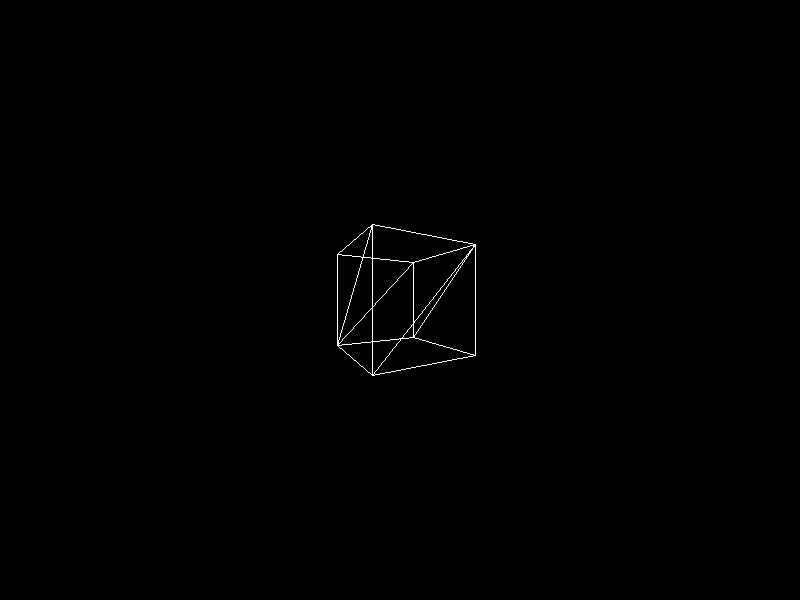

In [46]:
def render_triangle(img, triangle):
    v1, v2, v3 = triangle
    cv.line(img, (int(v1[0]), int(v1[1])), (int(v2[0]), int(v2[1])), 255)
    cv.line(img, (int(v2[0]), int(v2[1])), (int(v3[0]), int(v3[1])), 255)
    cv.line(img, (int(v3[0]), int(v3[1])), (int(v1[0]), int(v1[1])), 255)

img = cv.Mat(np.zeros((height, width)))
for triangle in cube_model:
    render_triangle(img, project_triangle(triangle))
    
retval, buf = cv.imencode(".jpeg", img)
IPython.display.Image(bytes(buf))